# MNIST dataset to be used

In [17]:
# Imports
import gzip
import os
from os.path import isfile, join
import numpy as np

In [18]:
mnist_path = './mnist_raw'

In [19]:
def list_files(mnist_path):
    return [join(mnist_path, f) for f in os.listdir(mnist_path) if isfile(join(mnist_path, f))]

In [20]:
# Testing the path and the files are correct
for f in list_files(mnist_path): print(f)

./mnist_raw/t10k-images-idx3-ubyte.gz
./mnist_raw/train-images-idx3-ubyte.gz
./mnist_raw/train-labels-idx1-ubyte.gz
./mnist_raw/t10k-labels-idx1-ubyte.gz


### Read files and extract data

In [21]:
def get_images(mnist_path):
    for f in list_files(mnist_path):
        if 'train-images' in f:
            with gzip.open(f, 'rb') as data:
                _ = int.from_bytes(data.read(4), 'big')
                num_images = int.from_bytes(data.read(4), 'big')
                rows = int.from_bytes(data.read(4), 'big')
                cols = int.from_bytes(data.read(4), 'big')
                train_images = data.read()
                x_train = np.frombuffer(train_images, dtype=np.uint8)
                x_train = x_train.reshape((num_images, rows, cols))
        elif 'train-labels' in f:
            with gzip.open(f, 'rb') as data:
                train_labels = data.read()[8:]
                y_train = np.frombuffer(train_labels, dtype=np.uint8)

        if 't10k-images' in f:
            with gzip.open(f, 'rb') as data:
                _ = int.from_bytes(data.read(4), 'big')
                num_images = int.from_bytes(data.read(4), 'big')
                rows = int.from_bytes(data.read(4), 'big')
                cols = int.from_bytes(data.read(4), 'big')
                test_images = data.read()
                x_test = np.frombuffer(test_images, dtype=np.uint8)
                x_test = x_test.reshape((num_images, rows, cols))
        elif 't10k-labels' in f:
            with gzip.open(f, 'rb') as data:
                test_labels = data.read()[8:]
                y_test = np.frombuffer(test_labels, dtype=np.uint8)
    
    return x_train, y_train, x_test, y_test

### Testing data shape

In [22]:
x_train, y_train, x_test, y_test = get_images(mnist_path)

In [23]:
print(x_train.shape)

(60000, 28, 28)


In [24]:
print(y_train.shape)

(60000,)


In [25]:
print(x_test.shape)

(10000, 28, 28)


In [26]:
print(y_test.shape)

(10000,)


#### Graph image

In [27]:
from jupyterthemes import jtplot
jtplot.style(grid=False)

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

In [29]:
def plot_number(image):
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')

La imagen mostrada corresponde a un: 4


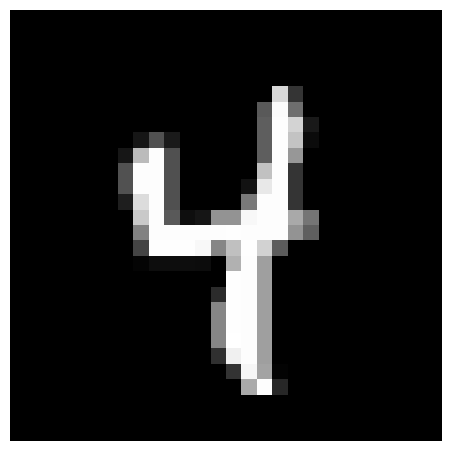

In [30]:
rand_idx = np.random.randint(len(y_test))
print(f'La imagen mostrada corresponde a un: {y_test[rand_idx]}')
plot_number(x_test[rand_idx])

### KNN

Using datasets with KNN model. With the imported versión dataset, the result was 97% eficient.

In [32]:
from collections import Counter
import multiprocessing as mp
cpu = mp.cpu_count()


def knn_predict(X_train, y_train, x, k):
    distances = [np.linalg.norm(x - x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    k_labels = y_train[k_indices]
    return Counter(k_labels).most_common()[0][0]


def mp_knn_predict(args):
    x, X_train, y_train, k = args
    return knn_predict(X_train, y_train, x, k)


def evaluate(predictions, y_test):
    accuracy = np.sum(predictions == y_test) / len(y_test)
    # for index, element in enumerate(predictions):
    #     print(f'{X_test[index]}, pred: {element}, expected: {y_test[index]}')
    return np.around(accuracy, 2)

In [33]:
# x_train, y_train, x_test, y_test
import time


k = 5

start = time.time()
normal_pred = [knn_predict(x_train, y_train, x, k) for x in x_test]
end = time.time()
print("\nKNN sin multiprocesamiento")
print(f"Accuracy: {evaluate(normal_pred, y_test)}, time: {end - start}")


KNN sin multiprocesamiento
Accuracy: 0.81, time: 4622.223835229874
